<center><b><font size="5">CLAS 2018 data study</font></b></center>

# Intro

In [1]:
import gepard as g
print('Gepard version = {}'.format(g.__version__))

Gepard version = 0.9.11b0


In [2]:
# This just gets my current git revision hash, in case version number above is not reliable.
# You should comment this cell out if your Gepard installation is not git cloned from github repository.
import os
import subprocess
branch = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                  'branch', '--show-current']).decode('ascii').strip()
revhash = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                   'rev-parse', 'HEAD']).decode('ascii').strip()
print('Current git branch is "{}" and revision hash is {}'.format(branch, revhash))

Current git branch is "dev_Mel" and revision hash is dd5e2aceae4d24c8f1365249b8d77a273a66969e


In [3]:
import gmaster as gm
from gmaster.fits import th_KM15, th_KM10b # need KM15 for simulated data
th15 = th_KM15

In [4]:
import gdevel as gd  # FT analysis is only here

In [5]:
import gepard.plots as gplot

In [6]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd 
import sys

In [7]:
sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepard/src/gepard/')

import mydatafiles
from mydatafiles import ep2epgamma

mydset = g.data.loaddata(mydatafiles)
mydset.update(g.data.loaddata(ep2epgamma))

In [8]:
mydset = g.data.loaddata(mydatafiles)

In [9]:
mydsetm = gm.data.loaddata(mydatafiles)

In [10]:
def plotpts(bin1, bin2=None, replica=None):
    """Plot points in bin with errorbars."""
    fig, ax = plt.subplots(1,1, figsize=[4,4])
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    if isinstance(bin2, pd.DataFrame):
        ax.errorbar(bin2.phi.values, bin2.val.values, bin2.err.values, color='red', linestyle='None',
                   capsize=2)
    if isinstance(replica, np.ndarray):
        ax.plot(bin1.phi.values, replica, marker='o', color='red', linestyle='None')
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [11]:
def plotbin(bin, th):
    """Plot points in bin with errorbars w.r.t. KM15."""
    fig, ax = plt.subplots(1,1, figsize=[4,4])
    bin1 = binXUU_df[bin]
    preds = []
    for pt in binXUU_pt[bin]:
        preds.append(th.predict(pt))
    preds = np.array(preds)
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    ax.plot(bin1.phi.values, preds, 'r-')
    # x.set_ylim(-0.5, 0.5)
    # ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [12]:
def gridplot(k):
    # phis = np.linspace(-np.pi, np.pi, 40)  # used for sine curve
    
    fig, axes = plt.subplots(3, 3, figsize=[12, 12])
    axes = axes.flatten()
    
    for i in range(9):
        ki = k + i
        df = binXUU_df[ki]
        ax = axes[i]
        
        ax.errorbar(df.phi.values, df.val.values, df.err.values, color='blue',
                    linestyle='None', capsize=3)
        
        # amp = df.iloc[0].FTval
        #ax.plot(phis, amp * np.sin(phis), color='red', linestyle='solid', lw=2)
        
        # ax.set_ylim(-0.5, 0.5)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_title(f'binXUU[{ki}]')
    
    plt.tight_layout()
    fig.savefig('fig_grid')

In [21]:
# New data from 2018
#CLAS18w = mydset.get(160, []) + mydset.get(161, []) + mydset.get(162, [])
fitpoints = (
    g.dset.get(101, []) + g.dset.get(102, []) + g.dset.get(8, [])  
    #+ g.dset.get(81, []) + g.dset.get(94, []) + g.dset.get(95, []) + g.dset.get(96, [])
    #+ mydset.get(150, []) # BSA 2023 CLAS
    # + mydset.get(182, []) + mydset.get(192, []) 
    #+ ACpts+ AULpts + ALLpts  # HERMES
    # HallA6w  # 2006(BSDw_byDM+BSSw+BSDovBSS)ß
    # g.dset.get(117, []) + g.dset.get(116, []) + g.dset.get(135, []) + g.dset.get(136, []) + g.dset.get(145, []) # 2015(BSDw+BSSw), 2017(BSDw+BSSw+X)  ##HallA
    # HallA15_XLUw + HallA15w + HallA17w
)   
g.describe_data(fitpoints)

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
12 x ALU     CLAS    -1.0   8   arXiv:0711.4805
48 x XLUw    CLAS    -1     101 arXiv:1504.02009
48 x XUUw    CLAS    0.0    102 arXiv:1504.02009
48 x XUUw    CLAS    1.0    102 arXiv:1504.02009
----------------------------------------------
TOTAL = 156


In [ ]:
# KK FTs
#g.describe_data(mydset[163])

KeyError: 163

# Q2-xB-t binning

In [16]:
dfXUU = mydset[160].df()[['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'err', 'errstat', 'errsyst']]

KeyError: 160

In [15]:
# Detect bin breaks based on increasing phi jumps
phi_diff = dfXUU['phi'].diff().fillna(0)
bin_starts = [0] + list(phi_diff[phi_diff > 2.5].index) + [len(dfXUU)]

# Initialize bin dictionary and list for bin centers
binXUU_df = {}
binXUU_pt = {}
bin_centers = []

# Loop over bins
for k in range(len(bin_starts) - 1):
    start = bin_starts[k]
    end = bin_starts[k + 1]
    df_bin = dfXUU.iloc[start:end].copy().reset_index(drop=True)
    
    
    # Compute central values
    Q2_mean = df_bin['Q2'].mean()
    xB_mean = df_bin['xB'].mean()
    tm_mean = df_bin['tm'].mean()
    
    # Add central values to each row of the bin
    df_bin['Q2_center'] = Q2_mean
    df_bin['xB_center'] = xB_mean
    df_bin['tm_center'] = tm_mean
    
    # Save
    binXUU_df[k] = df_bin
    binXUU_pt[k] = mydset[160][start:end]
    bin_centers.append({'Q2': Q2_mean, 'xB': xB_mean, 'tm': tm_mean})

# Create bins dataframe from collected central values
bins = pd.DataFrame(bin_centers)
print('Number of all bins = {}'.format(len(bins)))

NameError: name 'dfXUU' is not defined

In [19]:
f=open("bins.html", 'w')
f.write(bins.to_html())
f.close()

In [20]:
5353 - 64

5289

In [21]:
dfphi = mydset[160].df()

In [22]:
bin127 = dfphi.iloc[2278:2302][['Q2', 'xB', 't', 'phi', 'val', 'err']]

In [23]:
bin302 = dfphi.iloc[5289:5289+24][['Q2', 'xB', 't', 'phi', 'val', 'err']]

In [24]:
bin127.head()

,Q2,xB,t,phi,val,err
2278,tensor(2.8410),0.334,-0.264,tensor(3.0107),0.289071,0.022490
2279,tensor(2.8570),0.334,-0.264,tensor(2.7524),0.190125,0.020825
2280,tensor(2.8610),0.334,-0.264,tensor(2.4941),0.154017,0.012465
2281,tensor(2.8590),0.334,-0.264,tensor(2.2323),0.105575,0.008810
2282,tensor(2.8570),0.334,-0.263,tensor(1.9705),0.087878,0.010342


In [25]:
bin302.head()

,Q2,xB,t,phi,val,err


In [26]:
pt = mydset[163][302]

KeyError: 163

KeyError: 198

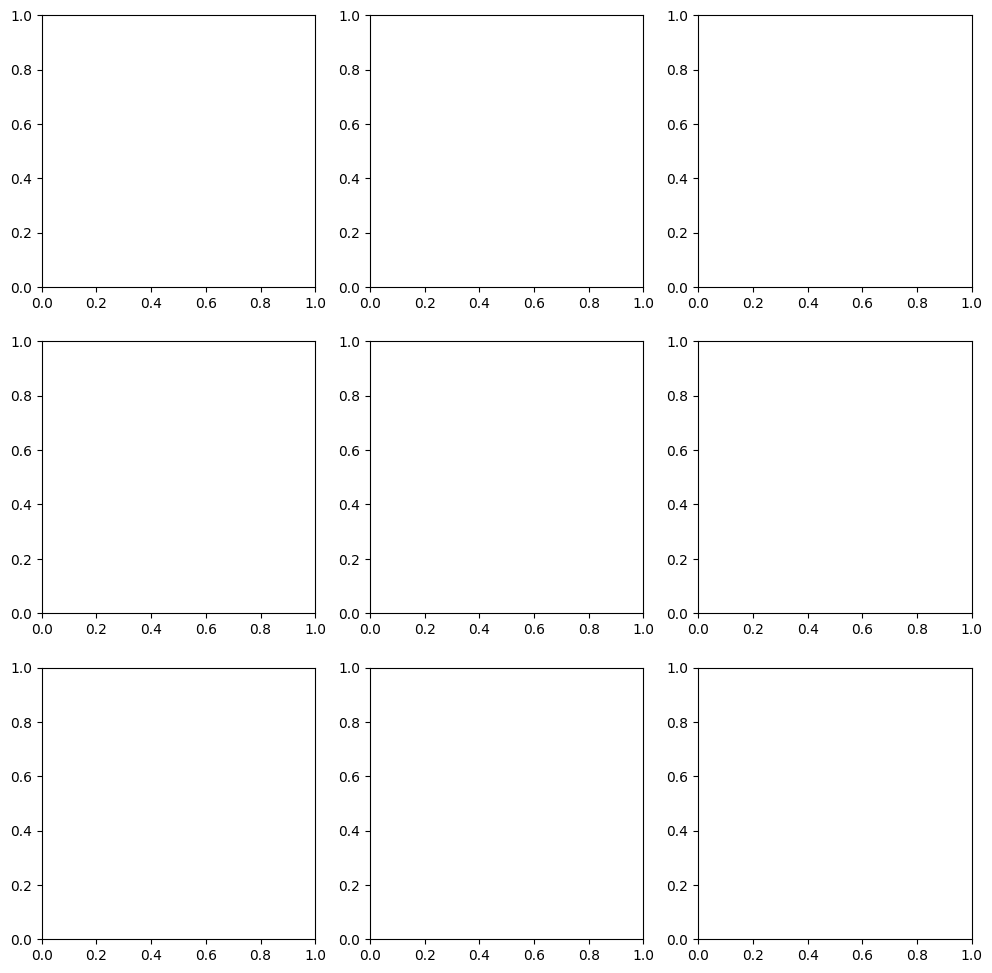

In [27]:
gridplot(198)

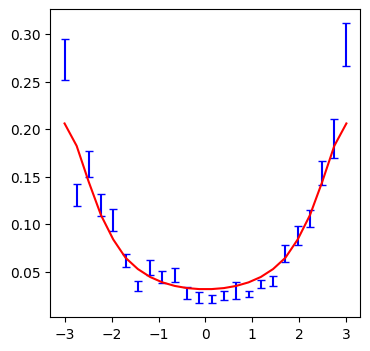

In [28]:
plotbin(127, th15)

# Calculating harmonics

In [29]:
cm = 2; sm = 2

In [30]:
dfphi = binXUU_df[58]  # Some example bin

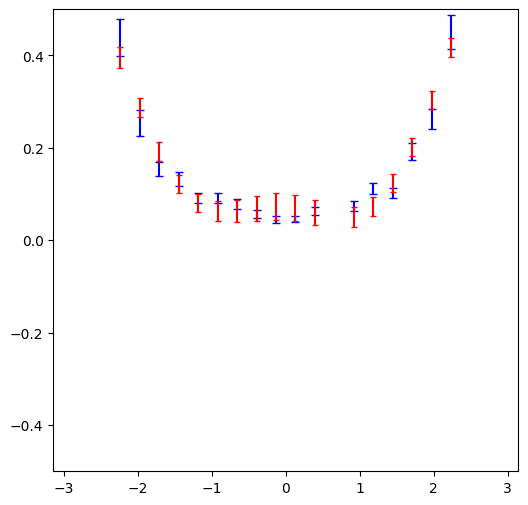

In [67]:
plotpts(dfphi, gd.data.FTFMC(gd.data.FTFMC(dfphi, cosmax=cm, sinmax=sm), inverse=True, cosmax=cm, sinmax=sm))

Above, double-FT red data should be statistically the same as the original blue data.

In [70]:
for k in range(len(bins)):
    dfFT = gd.data.FTFMC(binXUU_df[k], cosmax=cm, sinmax=sm, nsamples = 3000)
    binXUU_df[k]['FTval'] = pd.Series(dfFT['val'].values, index=binXUU_df[k].index)
    binXUU_df[k]['FTerr'] = pd.Series(dfFT['err'].values, index=binXUU_df[k].index)

In [102]:
def ci(bin, i):
    """Take just ith cosine harmonic of bin with error."""
    ind = i # index of cosine harmonic
    return bin[['Q2_center', 'xB_center', 'tm_center', 'in1energy', 'FTval', 'FTerr']].iloc[ind]

In [81]:
def si(bin, i):
    """Take just regardingfirst cosine harmonic of bin with error."""
    ind = cm+i # index of sine harmonic
    return bin[['Q2_center', 'xB_center', 'tm_center', 'in1energy', 'FTval', 'FTerr']].iloc[ind]

In [94]:
FTc0 = pd.DataFrame([pd.concat([ci(binXUU_df[k], 0),
                                pd.Series([binXUU_df[k]['errsyst'].mean(),
                                                     binXUU_df[k]['errsyst'].max()], index=['avgsyst', 'maxsyst'])])
                     for k in bins.index]).reset_index(drop=True)

In [95]:
FTc0['FTval'] = FTc0['FTval'].map(lambda x: '%.3f' % x)
FTc0['FTerr'] = FTc0['FTerr'].map(lambda x: '%.3f' % x)
FTc0['FTerrsyst'] = FTc0['avgsyst'].map(lambda x: '%.3f' % x)   # choose maxsyst to be conservative

In [96]:
FTc0['FTn'] = 0

In [97]:
f=open('c0.dat', 'w')
f.write(FTc0[['Q2_center', 'xB_center', 'tm_center', 'FTn', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))
f.close()

In [98]:
FTc1 = pd.DataFrame([pd.concat([ci(binXUU_df[k], 1),
                                pd.Series([binXUU_df[k]['errsyst'].mean(),
                                                     binXUU_df[k]['errsyst'].max()], index=['avgsyst', 'maxsyst'])])
                     for k in bins.index]).reset_index(drop=True)

In [99]:
FTc1['FTval'] = FTc1['FTval'].map(lambda x: '%.3f' % x)
FTc1['FTerr'] = FTc1['FTerr'].map(lambda x: '%.3f' % x)
FTc1['FTerrsyst'] = FTc1['avgsyst'].map(lambda x: '%.3f' % x)   # choose maxsyst to be conservative

In [100]:
FTc1['FTn'] = 1

In [101]:
f=open('c1.dat', 'w')
f.write(FTc1[['Q2_center', 'xB_center', 'tm_center', 'FTn', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))
f.close()

In [103]:
FTs1 = pd.DataFrame([pd.concat([si(binXUU_df[k], 1),
                                pd.Series([binXUU_df[k]['errsyst'].mean(),
                                                     binXUU_df[k]['errsyst'].max()], index=['avgsyst', 'maxsyst'])])
                     for k in bins.index]).reset_index(drop=True)

In [104]:
FTs1['FTval'] = FTs1['FTval'].map(lambda x: '%.3f' % x)
FTs1['FTerr'] = FTs1['FTerr'].map(lambda x: '%.3f' % x)
FTs1['FTerrsyst'] = FTs1['avgsyst'].map(lambda x: '%.3f' % x)   # choose maxsyst to be conservative

In [105]:
FTs1['FTn'] = -1

In [107]:
f=open('s1.dat', 'w')
f.write(FTs1[['Q2_center', 'xB_center', 'tm_center', 'FTn', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))
f.close()

## Comparison to Melany

In [133]:
mydsetm[163].df()[['Q2', 'xB', 't', 'FTn', 'val', 'err']][54:60]

,Q2,xB,t,FTn,val,err
54,1.931000,0.214909,-0.108545,0.0,1.190,0.086925
55,1.932600,0.215000,-0.153100,0.0,0.951,0.062682
56,1.935445,0.215000,-0.203111,0.0,0.561,0.035609
57,1.935445,0.215000,-0.262000,0.0,0.395,0.024839
58,1.935059,0.215000,-0.340353,0.0,0.255,0.016279
59,1.934813,0.215000,-0.447000,0.0,0.137,0.010630


In [147]:
# Corresponding datapoints from Melany's file
mydsetm[161].df()[['Q2', 'xB', 't', 'FTn', 'val', 'err']][338+54:338+60]

,Q2,xB,t,FTn,val,err
392,1.904,0.216,-0.108,0.0,0.775773,0.018031
393,1.908,0.215,-0.153,0.0,0.559589,0.012283
394,1.933,0.215,-0.204,0.0,0.357227,0.009031
395,1.934,0.215,-0.262,0.0,0.217432,0.005709
396,1.933,0.215,-0.341,0.0,0.125830,0.003453
397,1.932,0.215,-0.447,0.0,0.068944,0.002289


In [134]:
for pt in mydsetm[163][54:60]:
    print(pt.val, th15.predict(pt))

1.19 1.2137015806769635
0.951 1.018713477729526
0.561 0.8522329479931862
0.395 0.6904618451416513
0.255 0.505921572717414
0.137 0.30474965579717916


In [137]:
for pt in mydsetm[161][338+54:338+60]:
    print(pt.val, th15.predict(pt))

0.775773 1.0944990129909216
0.559589 0.9585601802124876
0.357227 0.8439226309407741
0.217432 0.6879261858849494
0.12583 0.5025983365186185
0.068944 0.3042541512363216


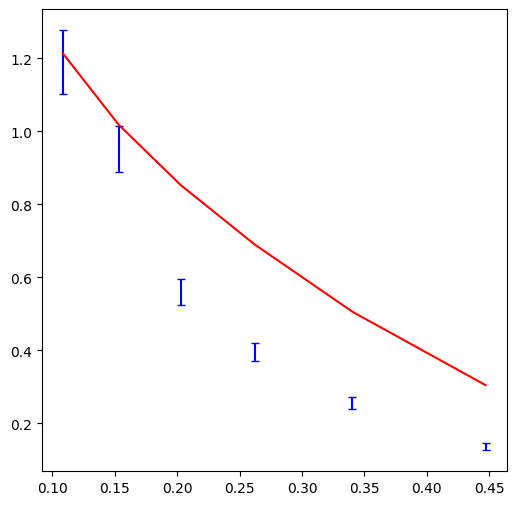

In [139]:
fig, ax = plt.subplots(1,1, figsize=[6,6])
dtst = mydsetm[163][54:60]
bin1 = dtst.df()
preds = []
for pt in dtst:
    preds.append(th15.predict(pt))
preds = np.array(preds)
ax.errorbar(bin1.tm.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
           capsize=3)
ax.plot(bin1.tm.values, preds, 'r-')
fig.savefig('fig')

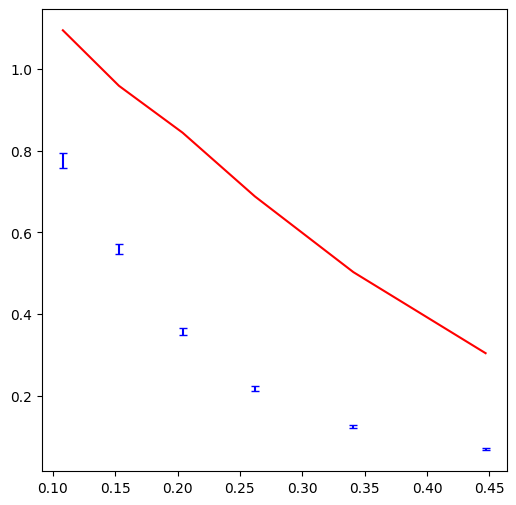

In [141]:
fig, ax = plt.subplots(1,1, figsize=[6,6])
dtst = mydsetm[161][338+54:338+60]
bin1 = dtst.df()
preds = []
for pt in dtst:
    preds.append(th15.predict(pt))
preds = np.array(preds)
ax.errorbar(bin1.tm.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
           capsize=3)
ax.plot(bin1.tm.values, preds, 'r-')
fig.savefig('fig')

## Size of harmonics

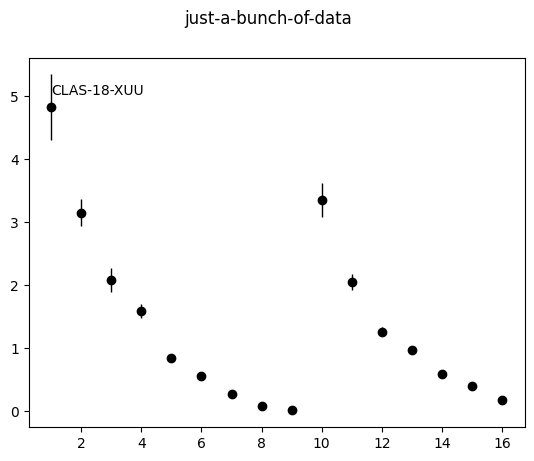

In [393]:
fig = gplot.jbod(points=g.select(mydset[163], criteria=['FTn == 0'])[:16])

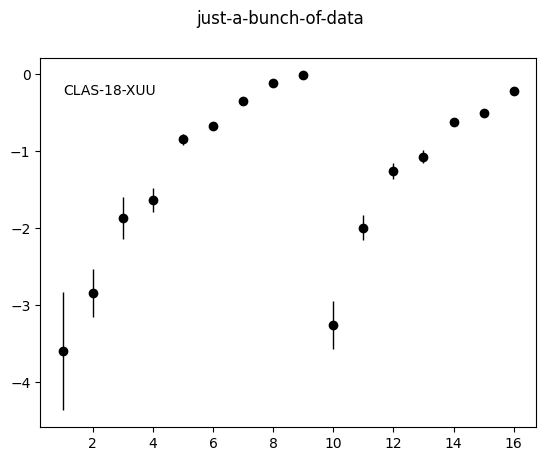

In [392]:
fig = gplot.jbod(points=g.select(mydset[163], criteria=['FTn == 1'])[:16])

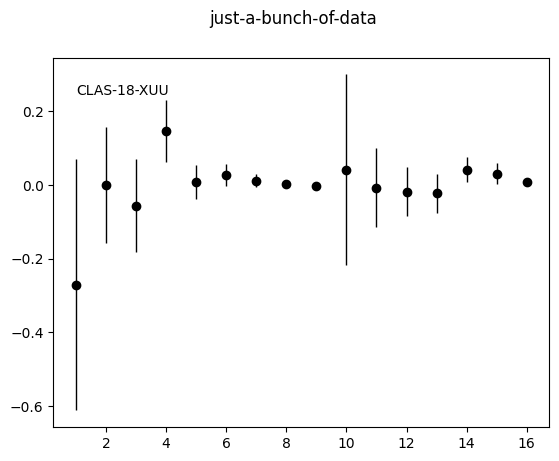

In [395]:
fig = gplot.jbod(points=g.select(mydset[163], criteria=['FTn == -1'])[:16])

So, no sine harmonic, but constant and cos(phi) are clearly visible and non-zero.

# Phi-dependent NN fitting

In [22]:
class NN(g.model.NeuralModel, g.eff.KellyEFF, g.dvcs.BM10tw2):

    def build_net(self):
            '''Overriding the default architecture and optimizer'''
            nn_model = torch.nn.Sequential(
                    torch.nn.Linear(3, 23),
                    torch.nn.ReLU(),
                    torch.nn.Linear(23, 37),
                    torch.nn.ReLU(),
                    torch.nn.Linear(37, 19),
                    torch.nn.ReLU(),
                    torch.nn.Linear(19, len(self.output_layer))
                )
            optimizer = torch.optim.Rprop(nn_model.parameters(), lr=0.01)
            return nn_model, optimizer

In [23]:
# 6 random bins
fitsets = [binXUU_pt[126][::3], binXUU_pt[67][::3], binXUU_pt[65][::3],
           binXUU_pt[158][::3], binXUU_pt[162][::3], binXUU_pt[128][::3]]

NameError: name 'binXUU_pt' is not defined

In [33]:
# some extra random bins
fitsets = [binXUU_pt[40][::3]+binXUU_pt[51][::3]+binXUU_pt[62][::3],
          binXUU_pt[70][::3]+binXUU_pt[82][::3]+binXUU_pt[91][::3],
          binXUU_pt[110][::3]+binXUU_pt[121][::3]+binXUU_pt[132][::3]]

In [25]:
th = NN(output_layer=['ImH', 'ReH', 'ReHt'], q2in=True, xpow=0)
f = g.fitter.NeuralFitter(fitpoints, th, nnets=3, batchlen=10, regularization='L2', lx_lambda=0.004)

In [26]:
f.fit()

Not supported yet


UnboundLocalError: cannot access local variable 'input_layer' where it is not associated with a value

In [319]:
for dset in fitsets:
    print(th.chisq(dset))

(np.float64(26.86507162530563), 16, np.float64(0.04300742851353356))
(np.float64(73.84104416692237), 22, np.float64(1.6228719246225154e-07))
(np.float64(20.86767081824407), 18, np.float64(0.286141723583649))


Not perfect but acceptable.

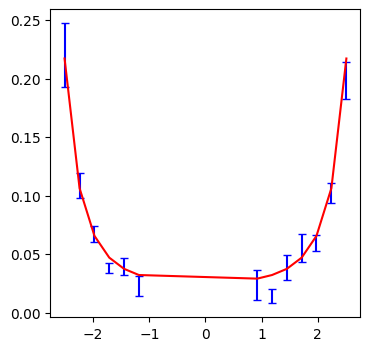

In [322]:
plotbin(51, th)

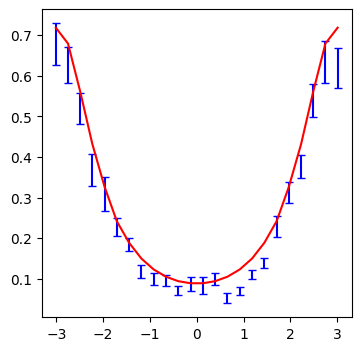

In [320]:
plotbin(91, th)

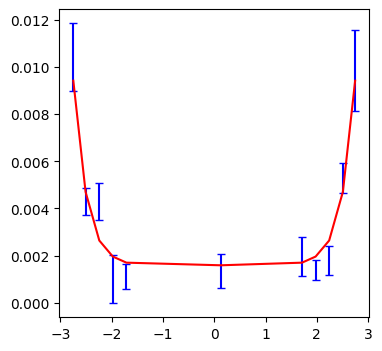

In [323]:
plotbin(148, th)

# Harmonic (unweighted) NN fitting

In [369]:
# some random subset of points
fitsets_harm_proto = [mydset[163][40:70:2], mydset[163][71:101:2], mydset[163][102:132:2]]

In [370]:
# Pruning datasets
fitsets_harm = []
for dset in fitsets_harm_proto:
    newset = []
    for pt in dset:
        if abs(pt.t) < pt.Q2/4:
            if abs(pt.err) < abs(pt.val)/3:
                newset.append(pt)
    newset = g.DataSet(newset)
    fitsets_harm.append(newset)

In [377]:
fitsets_harm.append(mydset[163][96:103])

In [378]:
th_harm = NN(output_layer=['ImH', 'ReH', 'ReHt'], q2in=True, xpow=0)
fh = g.fitter.NeuralFitter(fitsets_harm, th_harm, nnets=3, batchlen=10, regularization='L2', lx_lambda=0.002)

In [379]:
fh.fit()


Epoch  10: train error = 23.0500 test error = 235.3868 
Hopeless. Giving up

Epoch  10: train error = 7.2091 test error = 44.7146 -
Epoch  20: train error = 6.1382 test error = 40.2232 -
Epoch  30: train error = 5.3688 test error = 40.5793 +
Epoch  40: train error = 4.5754 test error = 50.1167 +
Epoch  50: train error = 4.4023 test error = 50.3087 +
Epoch  60: train error = 4.2846 test error = 54.5912 +
Epoch  70: train error = 4.2088 test error = 52.1478 +
No improvement for 5 batches. Stopping early.
Net 0 --> test_err = 40.22315953152387

Epoch  10: train error = 17.2694 test error = 12.2486 -
Epoch  20: train error = 16.0881 test error = 11.9790 -
Epoch  30: train error = 14.9867 test error = 12.8056 +
Epoch  40: train error = 14.4351 test error = 12.6833 +
Epoch  50: train error = 13.8983 test error = 12.8070 +
Epoch  60: train error = 12.4380 test error = 12.2835 +
Epoch  70: train error = 12.2788 test error = 12.4891 +
No improvement for 5 batches. Stopping early.
Net 1 --> tes

In [380]:
for dset in fitsets_harm:
    print(th_harm.chisq(dset))

(np.float64(435.5918666468563), 9, np.float64(0.0))
(np.float64(35.56692670266311), 8, np.float64(2.1072830723500857e-05))
(np.float64(40.337332413951515), 9, np.float64(6.600328329442462e-06))
(np.float64(5.8011832484327845), 7, np.float64(0.563146679602456))


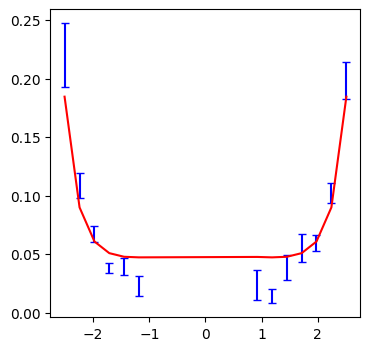

In [381]:
plotbin(51, th_harm)

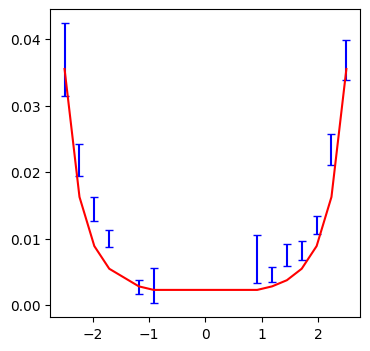

In [382]:
plotbin(97, th_harm)

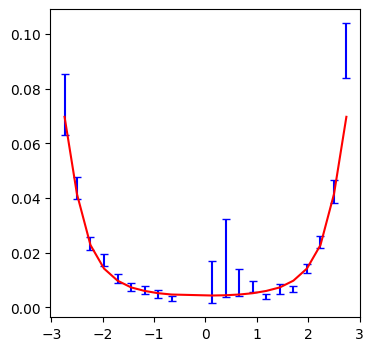

In [383]:
plotbin(146, th_harm)